In [19]:
import os

from dotenv import load_dotenv
load_dotenv()
groq_api_key=os.getenv("GROQ_API_KEY")


In [20]:
from langchain.chat_models import init_chat_model
model = init_chat_model("openai/gpt-oss-120b", model_provider="GROQ")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.2', 'langchain': '1.3.15'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002753490A870>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002753490B1D0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

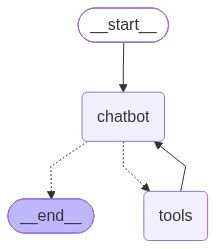

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	chatbot(chatbot)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> chatbot;
	chatbot -.-> __end__;
	chatbot -.-> tools;
	tools --> chatbot;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [28]:
from langchain_tavily import TavilySearch  ## for using inbuilt tools
from langchain_core.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition, tool_validator
from langgraph.types import Command, interrupt
from typing_extensions import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)


##Create a tool


@tool
def human_assistance(query: str) -> str:
    """Request the assistance from human"""
    human_message = interrupt({"query": query})
    return human_message["data"]


tool = TavilySearch(max_results=2)
tools = [tool, human_assistance]

##Create llm  with tools
llm = model.bind_tools(tools)

## Create Chatbot


def chatbot(state: State):
    messages = llm.invoke(state["messages"])
    # Beacuse we will interrupting during tool execution
    # we disable the parallel tool calling to avoid the repeating any
    # Tool invocation when we will resume
    return {"messages": messages}


graph_builder.add_node("chatbot", chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = MemorySaver()
from IPython.display import Image, display

graph = graph_builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))
graph = graph_builder.compile(checkpointer=memory)
print(graph.get_graph().draw_mermaid())

In [35]:
user_input="I need some expert guidance for building AI-agents. Could you please request assistance for me?"
config={"configurable":{"thread_id":"1"}}
events=graph.stream(
    {"messages":user_input},
        config,
        stream_mode="values"
    
)
events
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

I need some expert guidance for building AI-agents. Could you please request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b2cccce4-7bc0-496e-abd4-e278672d323c)
 Call ID: fc_b2cccce4-7bc0-496e-abd4-e278672d323c
  Args:
    query: User is seeking expert guidance on building AI agents. Please provide assistance.
================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b2cccce4-7bc0-496e-abd4-e278672d323c)
 Call ID: fc_b2cccce4-7bc0-496e-abd4-e278672d323c
  Args:
    query: User is seeking expert guidance on building AI agents. Please provide assistance.


In [36]:
human_resonse=("We, the experts are here to Help! we'd recommend you check out langgraph to build your agent")

human_command=Command(resume={"data":human_resonse})

events=graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_assistance (fc_b2cccce4-7bc0-496e-abd4-e278672d323c)
 Call ID: fc_b2cccce4-7bc0-496e-abd4-e278672d323c
  Args:
    query: User is seeking expert guidance on building AI agents. Please provide assistance.
================================= Tool Message =================================
Name: human_assistance

We, the experts are here to Help! we'd recommend you check out langgraph to build your agent
================================== Ai Message ==================================

Absolutely! Building AI‑agents can be a rewarding (and sometimes complex) journey, but with the right approach and tools you can get a robust, maintainable system up and running quickly. Below is a practical roadmap, along with recommended libraries, design patterns, and resources to help you move from “idea” to a production‑ready agent.

---

## 1️⃣ Clarify Your Agent’s Scope & Requirements

| Question | Why It